## Making of activity/weights

In [ ]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString
import numpy as np
import networkx as nx

In [2]:
GTFS_PATH = Path("../data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )
    
with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))
    routes = pd.read_csv(z.open("GTFS_Copenhagen/routes.txt"))
    shapes = pd.read_csv(z.open("GTFS_Copenhagen/shapes.txt"))
    stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))
    trips = pd.read_csv(z.open("GTFS_Copenhagen/trips.txt"))

/tmp/ipykernel_12810/146572828.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))


In [3]:
# stops filtering for metro only
metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]

# remove the line based on stop_id
metro_stops = metro_stops[metro_stops["stop_id"] != 821004401]

/tmp/ipykernel_12810/1801734949.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]


In [6]:
gdf_stops = gpd.GeoDataFrame(
    metro_stops,
    geometry=gpd.points_from_xy(metro_stops.stop_lon, metro_stops.stop_lat),
    crs="EPSG:4326"
)

gdf_stops_3857 = gdf_stops.to_crs(epsg=3857)

In [13]:
gdf_stops_3857.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code,geometry
51,8603317,NaN,Vestamager St. (Metro),NaN,55.619391,12.575297,0,NaN,0,NaN,POINT (1399875.659 7483017.289)
52,8603315,NaN,Ørestad St. (Metro),NaN,55.629055,12.579389,0,NaN,0,NaN,POINT (1400331.178 7484922.633)
53,8603312,NaN,Sundby St. (Metro),NaN,55.645199,12.585728,0,NaN,0,NaN,POINT (1401036.832 7488106.615)
54,8603313,NaN,Bella Center St. (Metro),NaN,55.638051,12.582928,0,NaN,0,NaN,POINT (1400725.138 7486696.697)
55,8603310,NaN,Islands Brygge St. (Metro),NaN,55.663422,12.585217,0,NaN,0,NaN,POINT (1400979.948 7491702.202)


based on this source:
https://metroselskabet.dk/en/about-us/about-the-metro/passenger-numbers-on-the-metro/

We find that our the number of passengers between stations are in the range 1000 - 36000 daily pssengers

In [ ]:
def find_weights(df):
    random.seed(154)
    updated_df = df.copy()
    updated_df["weight"] = ""
    for i in updated_df.index:
        updated_df.at[i, 'weight'] = random.randrange(1000, 36000, 500)
    return updated_df

In [39]:
gdf_stops_3857_weights = find_weights(gdf_stops_3857)

In [61]:
def neighbore_threshold_and_edge_dist(gdf_stops_3857):
    dict_nodes = {}

    gdf_utm = gdf_stops_3857.to_crs(gdf_stops_3857.estimate_utm_crs())
    gdf = gdf_utm[["stop_name", "geometry"]].dropna().reset_index(drop=True)
    # print(gdf)

    # x, y coordinates compatable to meters - two lists of coordinates
    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()

    threshold = 0

    for i, node in gdf.iterrows():
        dict_nodes[node["stop_name"]] = {}
        if len(xs) != len(ys):
            print("xs and ys is not same length")
            break
        
        temp_threshold = float('inf')
        for compare in range(len(xs)):
            if i == compare:
                continue
            dx = xs[i] - xs[compare]
            dy = ys[i] - ys[compare]
            d = np.hypot(dx, dy)
            other_stop = gdf.loc[compare, "stop_name"]
            dict_nodes[node["stop_name"]][other_stop] = d
            if d < temp_threshold:
                temp_threshold = d


        if temp_threshold > threshold:
            threshold = temp_threshold

    return threshold, dict_nodes


def within_treshold(threshold, dict_nodes, df):
    valid_connections = {}
    for node, neighbors in dict_nodes.items():
        for connection, distance_between_stations in neighbors.items():
            weight = df.loc[df["stop_name"] == connection, "weight"]
            if not weight.empty:
                weight = weight.values[0]
            if distance_between_stations <= threshold:
                if node in valid_connections:
                    valid_connections[node].append((connection, weight))
                else:
                    valid_connections[node] = [(connection, weight)]

    return valid_connections

## Start the algorithmn

In [120]:
# Parameters
max_routes = 4
max_stops = 17
min_stops = 13
threshold = 1350
total_kids = 5
total_number_of_node = 44

_, distance_dict = neighbore_threshold_and_edge_dist(gdf_stops_3857_weights)
valid_connections = within_treshold(threshold, distance_dict, gdf_stops_3857_weights)

accepted_kids = []

while len(accepted_kids) < total_kids:
    all_routes = {}
    potential_start = gdf_stops_3857_weights["stop_name"].tolist()

    used_nodes = set()  # <-- nodes already used in ANY completed route

    routes = 1

    edge_list = {}

    while routes < max_routes + 1:
        if not potential_start:
            break

        route_current = []
        start_node = random.choice(potential_start)
        route_current.append(start_node)

        while len(route_current) < max_stops:
            curr_node = route_current[-1]

            if curr_node in potential_start:
                potential_start.remove(curr_node)

            # filter out nodes already in this route
            poss_neighbors = [n for n in valid_connections[curr_node] if n[0] not in route_current]

            # dead-end handling
            if not poss_neighbors:
                if len(route_current) < min_stops:
                    route_current.reverse()
                    curr_node = route_current[-1]

                    poss_neighbors = [n for n in valid_connections[curr_node] if n[0] not in route_current]
                    if not poss_neighbors:
                        break
                else:
                    break


            neighbor_node = []
            neighbor_weights = []
            for i in poss_neighbors:
                neighbor_node.append(i[0])
                neighbor_weights.append(i[1])

            next_node = random.choices(neighbor_node, weights=neighbor_weights, k=1)[0]

            route_current.append(next_node)

            if curr_node in edge_list:
                edge_list[curr_node].append(next_node)
            else:
                edge_list[curr_node] = [next_node]

        all_routes[routes] = route_current
        routes += 1

    ## Check if its one componet 
    G = nx.from_dict_of_lists(edge_list)
    is_one_component = nx.is_connected(G)

    if is_one_component and G.number_of_nodes() == total_number_of_node:
        accepted_kids.append(all_routes)
    else:
        continue

In [121]:
accepted_kids

[{1: ['Nordhavn St. (Metro)',
   'Orientkaj St. (Metro)',
   'Poul Henningsens Plads St. (Metro)',
   'Vibenshus Runddel St. (Metro)',
   'Trianglen St. (Metro)',
   'Østerport St. (Metro)',
   'Marmorkirken St. (Metro)',
   'Nørreport St. (Metro)',
   'Gammel Strand St. (Metro)',
   'København H (Metro)',
   'Havneholmen St. (Metro)',
   'Enghave Plads St. (Metro)',
   'Frederiksberg Allé St. (Metro)',
   'Forum St. (Metro)',
   'Aksel Møllers Have St. (Metro)',
   'Fasanvej St. (Metro)',
   'Lindevang St. (Metro)'],
  2: ['Vanløse St. (Metro)',
   'Flintholm St. (Metro)',
   'Lindevang St. (Metro)',
   'Fasanvej St. (Metro)',
   'Aksel Møllers Have St. (Metro)',
   'Forum St. (Metro)',
   'Nørreport St. (Metro)',
   'Marmorkirken St. (Metro)',
   'Gammel Strand St. (Metro)',
   'Rådhuspladsen St. (Metro)',
   'Kongens Nytorv St. (Metro)',
   'Christianshavn St. (Metro)',
   'Amagerbro St. (Metro)',
   'DR Byen St. (Metro)',
   'Islands Brygge St. (Metro)'],
  3: ['København Syd St. (

### Evaluate the kids

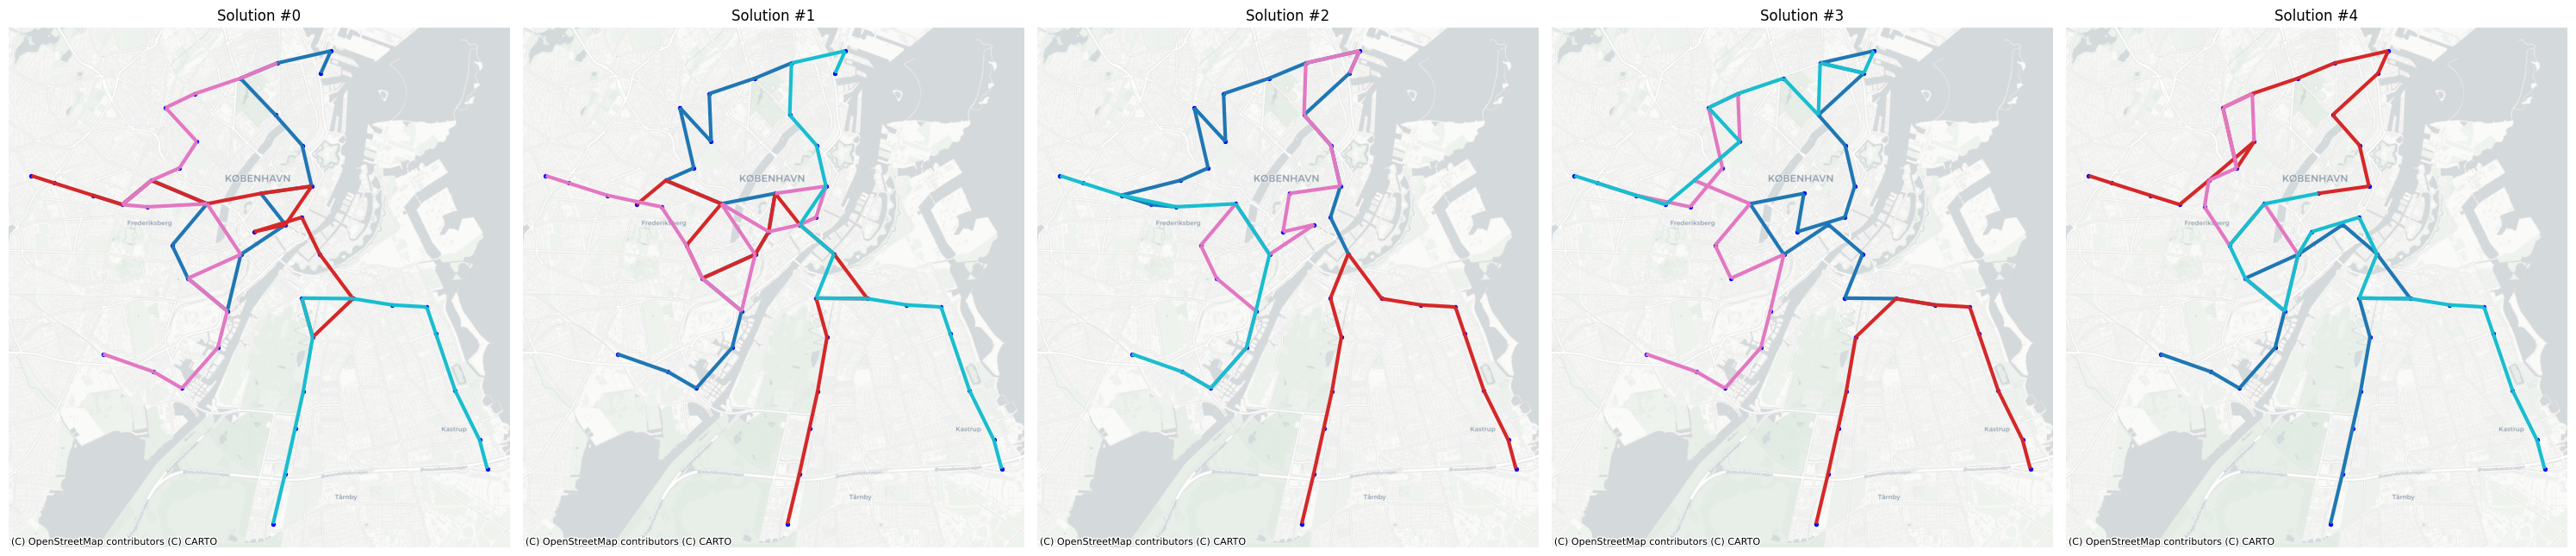

In [ ]:
def create_line(p1_name, p2_name, gdf_stops_3857):
    p1 = gdf_stops_3857.loc[
        gdf_stops_3857["stop_name"] == p1_name, "geometry"
    ].iloc[0]
    p2 = gdf_stops_3857.loc[
        gdf_stops_3857["stop_name"] == p2_name, "geometry"
    ].iloc[0]
    return LineString([p1, p2])


def build_edges_gdf(solution_routes_dict, gdf_stops_3857):
    records = []

    for route_id, route in solution_routes_dict.items():
        for k in range(len(route) - 1):
            p1 = route[k]
            p2 = route[k + 1]

            line = create_line(p1, p2, gdf_stops_3857)

            records.append({
                "geometry": line,
                "route_id": route_id
            })

    return gpd.GeoDataFrame(records, crs=gdf_stops_3857.crs)


# ---- MAIN PLOT ----

n = len(accepted_kids)

fig, axes = plt.subplots(
    1, n,
    figsize=(6 * n, 8),
    sharex=True,
    sharey=True
)

# If only 1 solution, axes is not iterable
if n == 1:
    axes = [axes]

for idx, solution_dict in enumerate(accepted_kids):

    ax = axes[idx]

    edges_gdf = build_edges_gdf(solution_dict, gdf_stops_3857)

    edges_gdf.plot(
        ax=ax,
        column="route_id",
        categorical=True,
        legend=False,  # better to disable multiple legends
        linewidth=3
    )

    gdf_stops_3857.plot(ax=ax, color="blue", markersize=8)

    cx.add_basemap(
        ax,
        source=cx.providers.CartoDB.Positron,
        crs=gdf_stops_3857.crs
    )

    ax.set_title(f"Solution #{idx}")
    ax.set_axis_off()
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()
